# BrainGNN-style Regression


## 1. Check GPU & RAM

In [ ]:
import torch, psutil, sys

ram_gb = psutil.virtual_memory().total / 1024**3
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
print(f"RAM     : {ram_gb:.1f} GB")
if not torch.cuda.is_available():
    print("\n⚠️  No GPU — Runtime → Change runtime type → GPU")
else:
    print("\n✓ Ready.")


Python  : 3.12.13
PyTorch : 2.11.0+cu128
CUDA    : 12.8
GPU     : NVIDIA L4
VRAM    : 22.0 GB
RAM     : 53.0 GB

✓ Ready.


## 2. Install Dependencies

In [ ]:
import subprocess, sys, torch

def install_pyg():
    tv  = torch.__version__.split("+")[0]
    cv  = torch.version.cuda.replace(".", "")
    url = f"https://data.pyg.org/whl/torch-{tv}+cu{cv}.html"
    print(f"PyG wheel: torch-{tv}+cu{cv}")
    pkgs = ["torch-scatter","torch-sparse","torch-cluster",
            "torch-spline-conv","torch-geometric"]
    r = subprocess.run(
        [sys.executable,"-m","pip","install","--quiet","-f",url]+pkgs,
        capture_output=True, text=True)
    if r.returncode != 0:
        subprocess.run([sys.executable,"-m","pip","install","--quiet",
                        "torch-geometric"], check=True)
    print("✓ PyG installed.")

install_pyg()
subprocess.run([sys.executable,"-m","pip","install","--quiet",
                "nilearn","nibabel","scipy"], check=True)
print("✓ All packages ready.")


PyG wheel: torch-2.11.0+cu128
✓ PyG installed.
✓ All packages ready.


## 3. Mount Drive & Configure

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
from pathlib import Path

# ── UPDATE THESE ──────────────────────────────────────────────────────────────
PICKLE_PATH = "/content/drive/MyDrive/all_sub_PMAT24_A_CR/graphs_outer5_inner5.pkl"
ATLAS_NII   = "/content/drive/MyDrive/shen_2mm_268_parcellation.nii.gz"
OUTPUT_DIR  = Path("/content/drive/MyDrive/brain_gnn_full/results/braingnn_outer1_inner1_last")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
SEED           = 42
BATCH_SIZE     = 64       # larger batch = fewer iterations per epoch = faster
LR             = 3e-4
WEIGHT_DECAY   = 1e-4
EPOCHS         = 100
PATIENCE       = 15
N_ROI          = 268
HIDDEN_DIM     = 64
POOLING_RATIO  = 0.5      # keep top 50% = 134 nodes after pool1
N_CLUSTERS     = 8        # one per Shen network
DROPOUT        = 0.3
LAMBDA1        = 0.1      # unit loss weight
LAMBDA2        = 0.3      # TPK loss weight
LAMBDA3        = 0.05     # GLC loss weight (smaller — less critical)

for label, path in [("Pickle", PICKLE_PATH), ("Atlas", ATLAS_NII)]:
    exists = os.path.exists(path)
    size   = f"({os.path.getsize(path)/1024**3:.2f} GB)" if exists else ""
    print(f"{'✓' if exists else '❌'}  {label}: {path} {size}")


Mounted at /content/drive
✓  Pickle: /content/drive/MyDrive/all_sub_PMAT24_A_CR/graphs_outer5_inner5.pkl (17.70 GB)
✓  Atlas: /content/drive/MyDrive/shen_2mm_268_parcellation.nii.gz (0.00 GB)


## 4. All Definitions — Model, Losses, Helpers

In [ ]:
import os, gc, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import psutil
from tqdm.notebook import tqdm
from scipy.stats import spearmanr
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader

def ram_used():
    u = psutil.virtual_memory().used  / 1024**3
    t = psutil.virtual_memory().total / 1024**3
    print(f"  RAM: {u:.1f}/{t:.1f} GB ({100*u/t:.0f}%)")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(SEED)


# =============================================================================
# Ra-GConv: ROI-aware Graph Convolution  (fully vectorised)
# =============================================================================
# Each ROI is soft-assigned to one of N_CLUSTERS clusters via a learnable
# assignment matrix. Cluster embeddings are mixed using the assignment weights.
# NO Python loops — everything is batched matrix multiplication on GPU.

class RaGConv(nn.Module):
    def __init__(self, in_channels, out_channels, n_roi=268, n_clusters=8):
        super().__init__()
        # One linear per cluster — stored as a single weight tensor for speed
        # Shape: [n_clusters, in_channels, out_channels]
        self.W = nn.Parameter(
            torch.randn(n_clusters, in_channels, out_channels) * 0.01)
        # Soft ROI→cluster assignment [n_roi, n_clusters]
        self.roi_assign = nn.Parameter(torch.randn(n_roi, n_clusters) * 0.1)
        self.gcn   = GCNConv(out_channels, out_channels, add_self_loops=True)
        self.bn    = nn.BatchNorm1d(out_channels)
        self.n_roi = n_roi

    def forward(self, x, edge_index):
        n_nodes = x.size(0)
        # Map each node to its ROI index (nodes cycle: 0,1,...,n_roi-1,0,...)
        roi_idx = torch.arange(n_nodes, device=x.device) % self.n_roi

        # Soft assignment: [n_nodes, n_clusters]
        assign = F.softmax(self.roi_assign[roi_idx], dim=-1)

        # Cluster-conditioned embedding (vectorised):
        # x: [n_nodes, in_channels]
        # W: [n_clusters, in_channels, out_channels]
        # x @ W[c]: [n_nodes, out_channels] for each cluster c
        # assign[:, c]: [n_nodes] weight for cluster c
        # Result: sum_c assign[:,c] * (x @ W[c])

        # Efficient: x unsqueeze → [n_nodes, 1, in_channels]
        # W: [n_clusters, in_channels, out_channels]
        # einsum: [n_nodes, n_clusters, out_channels]
        x_exp    = x.unsqueeze(1)                          # [N, 1, in_ch]
        x_clust  = torch.einsum('nci,cio->nco', x_exp.expand(
            -1, self.W.size(0), -1), self.W)               # [N, C, out_ch]
        assign_e = assign.unsqueeze(-1)                    # [N, C, 1]
        x_embed  = (x_clust * assign_e).sum(dim=1)        # [N, out_ch]

        # Graph convolution + BN + ReLU
        x_out = self.gcn(x_embed, edge_index)
        x_out = self.bn(x_out)
        return F.relu(x_out)

    def get_assignment(self):
        return F.softmax(self.roi_assign, dim=-1).detach().cpu().numpy()


# =============================================================================
# R-pool: ROI-selection TopK Pooling  (fully vectorised — no Python loops)
# =============================================================================

class RPool(nn.Module):
    def __init__(self, in_channels, ratio=0.5, n_roi=268):
        super().__init__()
        self.ratio     = ratio
        self.n_roi     = n_roi
        self.score_proj = nn.Linear(in_channels, 1, bias=False)

    def forward(self, x, edge_index, batch):
        n_nodes  = x.size(0)
        n_graphs = int(batch.max().item()) + 1

        # ── Step 1: score every node ──────────────────────────────────────
        scores = self.score_proj(x).squeeze(-1)                # [n_nodes]
        scores = scores / (self.score_proj.weight.norm() + 1e-8)

        # ── Step 2: vectorised top-K per graph ────────────────────────────
        # Strategy: add a large per-graph offset so nodes from graph g
        # sort above all nodes from graph g-1. Then global topk selects
        # the right nodes without any Python loop.
        graph_sizes  = torch.bincount(batch, minlength=n_graphs).float()
        k_per_graph  = (graph_sizes * self.ratio).long().clamp(min=1) # [n_graphs]
        total_keep   = int(k_per_graph.sum().item())

        # Offset: large enough so graph ordering is preserved
        offset_scale = scores.abs().max().detach() + 1.0
        offsets      = batch.float() * offset_scale * 2        # [n_nodes]
        scores_shift = scores + offsets                         # [n_nodes]

        # Global argsort descending → top nodes per graph come first
        global_order = torch.argsort(scores_shift, descending=True)

        # ── Step 3: build keep mask using cumulative graph counts ─────────
        # For each position in sorted order, which graph does it belong to?
        sorted_graphs = batch[global_order]                    # [n_nodes]

        # Rank of each node within its graph (in score-descending order)
        # Use cumcount trick: for each graph, count how many times it has
        # appeared so far in the sorted list
        ones    = torch.ones(n_nodes, device=x.device)
        # Running count per graph using scatter — we need a per-position rank
        # Trick: assign each node a unique within-graph position via sort
        graph_order = torch.zeros(n_nodes, dtype=torch.long, device=x.device)

        # Fully vectorised within-graph rank:
        # 1. Sort by (batch, -score) to get within-graph ordering
        # 2. Use cumsum within groups
        sort_key       = batch * n_nodes + torch.argsort(
            torch.argsort(scores_shift, descending=True))      # unique rank
        within_rank    = torch.argsort(sort_key)               # [n_nodes]
        # within_rank[i] = position of node i in (batch, score-desc) order
        # But we want rank within each graph:
        # Recompute properly:
        # sorted_idx: nodes sorted by (graph asc, score desc)
        secondary_sort = scores_shift * -1                     # desc score
        combined_sort  = batch.float() * (offset_scale * 4) + secondary_sort
        graph_score_order = torch.argsort(combined_sort)       # [n_nodes]
        # Position of each node in this ordering
        inv_order = torch.argsort(graph_score_order)           # [n_nodes]
        # Within-graph rank = inv_order - cumulative offset for that graph
        graph_start = torch.zeros(n_graphs + 1, dtype=torch.long, device=x.device)
        graph_start[1:] = torch.cumsum(k_per_graph * 0 + graph_sizes.long(), dim=0)
        within_graph_rank = inv_order - graph_start[batch]     # [n_nodes]

        # Keep node if its within-graph rank < k_per_graph[graph]
        keep_mask = within_graph_rank < k_per_graph[batch]    # [n_nodes] bool
        perm      = keep_mask.nonzero(as_tuple=False).squeeze(-1)

        # ── Step 4: apply gating ──────────────────────────────────────────
        x_out = x[perm] * torch.sigmoid(scores[perm]).unsqueeze(-1)

        # ── Step 5: filter edges (vectorised) ────────────────────────────
        node_remap = torch.full((n_nodes,), -1, dtype=torch.long, device=x.device)
        node_remap[perm] = torch.arange(perm.size(0), device=x.device)

        src, dst   = edge_index
        keep_edges = (node_remap[src] >= 0) & (node_remap[dst] >= 0)
        edge_out   = node_remap[edge_index[:, keep_edges]]

        batch_out  = batch[perm]
        return x_out, edge_out, batch_out, scores, perm


# =============================================================================
# Interpretability Loss Terms
# =============================================================================

def unit_loss(weight):
    return (weight.norm() - 1.0) ** 2


def topk_pooling_loss(scores, perm, batch_pre_pool, lam=0.5):
    """
    scores        : [n_nodes]  pre-pool scores for ALL nodes
    perm          : [n_kept]   indices of kept nodes
    batch_pre_pool: [n_nodes]  batch vector BEFORE pool (matches scores)
    """
    n = scores.size(0)
    sel = torch.zeros(n, dtype=torch.bool, device=scores.device)
    sel[perm] = True
    s_sel   = scores[sel]
    s_unsel = scores[~sel]
    if s_sel.numel() == 0 or s_unsel.numel() == 0:
        return scores.sum() * 0
    return -s_sel.mean() + s_unsel.mean() + lam * (scores ** 2).mean()


def glc_loss(scores, targets, batch_pre_pool, n_bins=4):
    """
    scores        : [n_nodes]  pre-pool scores
    targets       : [n_graphs] one target per graph  (data.y)
    batch_pre_pool: [n_nodes]  batch vector BEFORE pool (matches scores)
    """
    n_graphs = int(batch_pre_pool.max().item()) + 1
    if n_graphs < 2:
        return scores.sum() * 0

    # Mean score per graph — fully vectorised with scatter
    count = torch.bincount(batch_pre_pool, minlength=n_graphs).float()
    score_sum = torch.zeros(n_graphs, device=scores.device).scatter_add(
        0, batch_pre_pool, scores)
    mean_scores = score_sum / (count + 1e-8)               # [n_graphs]

    # Bin subjects by target score
    t_np    = targets.detach().cpu().numpy()
    n_bins  = min(n_bins, max(2, n_graphs // 2))
    bins    = np.quantile(t_np, np.linspace(0, 1, n_bins + 1))
    bins[0] -= 1e-8; bins[-1] += 1e-8

    glc = scores.sum() * 0   # zero with grad
    n_valid = 0
    for b in range(n_bins):
        mask = (t_np >= bins[b]) & (t_np < bins[b+1])
        idx  = torch.tensor(np.where(mask)[0], device=scores.device, dtype=torch.long)
        if idx.numel() < 2:
            continue
        glc     += mean_scores[idx].var()
        n_valid += 1

    return glc / max(n_valid, 1)


# =============================================================================
# BrainGNNRegressor — Full Model
# =============================================================================

class BrainGNNRegressor(nn.Module):
    def __init__(self, in_dim=268, hidden_dim=64, pooling_ratio=0.5,
                 n_roi=268, n_clusters=8, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        self.conv1  = RaGConv(in_dim,     hidden_dim, n_roi, n_clusters)
        self.conv1b = RaGConv(hidden_dim, hidden_dim, n_roi, n_clusters)
        self.pool1  = RPool(hidden_dim, ratio=pooling_ratio, n_roi=n_roi)

        self.conv2  = RaGConv(hidden_dim, hidden_dim, n_roi, n_clusters)
        self.conv2b = RaGConv(hidden_dim, hidden_dim, n_roi, n_clusters)
        self.pool2  = RPool(hidden_dim, ratio=pooling_ratio, n_roi=n_roi)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),         nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, data, return_scores=False):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, ei)
        x = self.conv1b(x, ei)
        x, ei, batch, scores1, perm1 = self.pool1(x, ei, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, ei)
        x = self.conv2b(x, ei)
        x, ei, batch, _, _ = self.pool2(x, ei, batch)
        x    = global_mean_pool(x, batch)
        pred = self.head(x).squeeze(-1)
        if return_scores:
            return pred, scores1, perm1
        return pred

    def get_interpretability_losses(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, ei)
        x = self.conv1b(x, ei)

        # Save pre-pool1 batch — CRITICAL FIX
        batch_pre_pool1 = batch.clone()

        x, ei, batch, scores1, perm1 = self.pool1(x, ei, batch)

        # Interpretability losses — all use pre-pool1 batch and scores
        l_unit = unit_loss(self.pool1.score_proj.weight)
        l_tpk  = topk_pooling_loss(scores1, perm1, batch_pre_pool1)
        l_glc  = glc_loss(scores1, data.y, batch_pre_pool1)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, ei)
        x = self.conv2b(x, ei)
        x, ei, batch, _, _ = self.pool2(x, ei, batch)
        x    = global_mean_pool(x, batch)
        pred = self.head(x).squeeze(-1)
        return pred, l_unit, l_tpk, l_glc


# =============================================================================
# Data helpers
# =============================================================================

def flatten_and_filter(arr2d):
    flat = []
    for subj_idx, row in enumerate(arr2d):
        for g in row:
            if hasattr(g, 'pad') and bool(g.pad):
                continue
            g.subject_id = torch.tensor([subj_idx])
            flat.append(g)
    return flat

def normalize_targets(graphs_list, scaler=None, fit=True):
    if not graphs_list:
        return graphs_list, scaler
    targets = np.array([g.y.item() for g in graphs_list]).reshape(-1,1)
    if scaler is None:
        scaler = StandardScaler()
    tn = scaler.fit_transform(targets) if fit else scaler.transform(targets)
    for i, g in enumerate(graphs_list):
        g.y = torch.tensor(float(tn[i,0]), dtype=torch.float32)
    return graphs_list, scaler

def load_fold(path):
    print("Loading pkl...")
    graphs     = torch.load(path, map_location="cpu", weights_only=False)
    train_list = flatten_and_filter(graphs["train_graphs"])
    val_list   = flatten_and_filter(graphs["val_graphs"])
    test_list  = flatten_and_filter(graphs["test_graphs"])
    del graphs; gc.collect()
    train_list, scaler = normalize_targets(train_list, fit=True)
    val_list,   _      = normalize_targets(val_list,   scaler, fit=False)
    test_list,  _      = normalize_targets(test_list,  scaler, fit=False)
    return train_list, val_list, test_list, scaler

SHEN_NETWORKS = [
    (range(1,   30), "Medial Frontal"),
    (range(30,  65), "Frontoparietal"),
    (range(65,  113),"Default Mode"),
    (range(113, 148),"Subcortical / Cerebellum"),
    (range(148, 170),"Motor"),
    (range(170, 199),"Visual I"),
    (range(199, 226),"Visual II"),
    (range(226, 269),"Visual Association"),
]

def roi_network(idx_0based):
    label = idx_0based + 1
    for rng, name in SHEN_NETWORKS:
        if label in rng: return name
    return "Unknown"

def compute_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    if len(y_true) > 2:
        r, p  = spearmanr(y_true, y_pred)
        r2    = r2_score(y_true, y_pred)
    else:
        r = p = r2 = float('nan')
    return dict(mse=float(mse), mae=float(mae), rmse=float(np.sqrt(mse)),
                r=float(r), r2=float(r2), p_value=float(p))

print("✓ All definitions loaded.")


✓ All definitions loaded.


## 5. Load Data

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
ram_used()

train_graphs, val_graphs, test_graphs, scaler = load_fold(PICKLE_PATH)
in_dim    = train_graphs[0].x.size(-1)
fold_name = Path(PICKLE_PATH).stem

print(f"\nFold     : {fold_name}")
print(f"Train    : {len(train_graphs)} windows, "
      f"{len(set(g.subject_id.item() for g in train_graphs))} subjects")
print(f"Val      : {len(val_graphs)} windows, "
      f"{len(set(g.subject_id.item() for g in val_graphs))} subjects")
print(f"Test     : {len(test_graphs)} windows, "
      f"{len(set(g.subject_id.item() for g in test_graphs))} subjects")
print(f"Node dim : {in_dim}")
ram_used()

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print("\n✓ DataLoaders ready.")


Device: cuda
  RAM: 2.0/53.0 GB (4%)
Loading pkl...

Fold     : graphs_outer5_inner5
Train    : 10620 windows, 118 subjects
Val      : 2610 windows, 29 subjects
Test     : 3240 windows, 36 subjects
Node dim : 268
  RAM: 20.1/53.0 GB (38%)

✓ DataLoaders ready.


## 6. Build Model & Optimiser

In [ ]:
model = BrainGNNRegressor(
    in_dim=in_dim,
    hidden_dim=HIDDEN_DIM,
    pooling_ratio=POOLING_RATIO,
    n_roi=N_ROI,
    n_clusters=N_CLUSTERS,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters : {n_params:,}")
print(f"Pool1 keeps: {int(N_ROI*POOLING_RATIO)}/{N_ROI} nodes")
print(f"Pool2 keeps: {int(N_ROI*POOLING_RATIO**2)}/{N_ROI} nodes")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10)
print("\n✓ Model ready.")

# ── Timing test: one batch ───────────────────────────────────────────────────
import time
model.train()
test_batch = next(iter(train_loader)).to(device)
t0 = time.time()
with torch.no_grad():
    _ = model(test_batch)
torch.cuda.synchronize()
t1 = time.time()
n_batches = len(train_loader)
est_epoch = (t1 - t0) * n_batches
print(f"\nOne batch: {(t1-t0)*1000:.1f} ms")
print(f"Estimated epoch time: {est_epoch/60:.1f} min  ({n_batches} batches)")
print(f"Estimated total ({EPOCHS} ep): {est_epoch*EPOCHS/3600:.1f} hr  "
      f"(early stopping ~{est_epoch*20/60:.0f} min if converges at ep 20)")


Parameters : 267,649
Pool1 keeps: 134/268 nodes
Pool2 keeps: 67/268 nodes

✓ Model ready.

One batch: 1369.1 ms
Estimated epoch time: 3.8 min  (166 batches)
Estimated total (100 ep): 6.3 hr  (early stopping ~76 min if converges at ep 20)


## 7. Train / Eval Functions

In [ ]:
def train_one_epoch(model, loader, optimizer, device,
                    lam1=LAMBDA1, lam2=LAMBDA2, lam3=LAMBDA3):
    model.train()
    mse_fn = nn.MSELoss()
    total_loss = 0.0
    n = 0
    for batch in loader:
        batch = batch.to(device)
        pred, l_unit, l_tpk, l_glc = model.get_interpretability_losses(batch)
        target = batch.y.view_as(pred)
        loss   = mse_fn(pred, target) + lam1*l_unit + lam2*l_tpk + lam3*l_glc
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        n          += batch.num_graphs
    return total_loss / n


@torch.no_grad()
def evaluate_subject_level(model, graphs_list, device, scaler, batch_size=128):
    model.eval()
    pred_sums   = defaultdict(float)
    pred_counts = defaultdict(int)
    true_scores = {}
    loader = DataLoader(graphs_list, batch_size=batch_size, shuffle=False)
    for batch in loader:
        batch = batch.to(device)
        pred  = model(batch).cpu().numpy()
        sids  = batch.subject_id.cpu().numpy().flatten()
        ys    = batch.y.cpu().numpy()
        for p, sid, y in zip(pred, sids, ys):
            pred_sums[sid]   += float(p)
            pred_counts[sid] += 1
            true_scores[sid]  = float(y)
    subject_ids  = sorted(pred_sums.keys())
    preds_norm   = np.array([pred_sums[s]/pred_counts[s] for s in subject_ids])
    trues_norm   = np.array([true_scores[s]              for s in subject_ids])
    preds_orig   = scaler.inverse_transform(preds_norm.reshape(-1,1)).flatten()
    trues_orig   = scaler.inverse_transform(trues_norm.reshape(-1,1)).flatten()
    return compute_metrics(trues_orig, preds_orig)

print("✓ Training functions defined.")


✓ Training functions defined.


## 8. Training Loop

In [ ]:
import time

checkpoint_path = OUTPUT_DIR / f"{fold_name}_braingnn_best.pt"

best_val_r     = -np.inf
best_epoch     = 0
patience_count = 0
history        = []

print(f"Training up to {EPOCHS} epochs (patience={PATIENCE})")
print(f"Checkpoint → {checkpoint_path}\n")

for epoch in range(1, EPOCHS + 1):
    t0         = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_m      = evaluate_subject_level(model, val_graphs, device, scaler)
    scheduler.step(val_m["mse"])
    ep_time    = time.time() - t0

    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_r": val_m["r"], "val_mse": val_m["mse"],
                    "val_mae": val_m["mae"]})

    improved = val_m["r"] > best_val_r
    tag      = "  ← best" if improved else ""
    print(f"Ep {epoch:03d} | Loss {train_loss:.4f} | "
          f"Val R {val_m['r']:.4f} | MAE {val_m['mae']:.4f} | "
          f"{ep_time:.0f}s{tag}")

    if improved:
        best_val_r = val_m["r"]; best_epoch = epoch; patience_count = 0
        torch.save({"model_state_dict": model.state_dict(),
                    "epoch": epoch, "val_r": best_val_r,
                    "in_dim": in_dim}, checkpoint_path)
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\n✓ Best Val R = {best_val_r:.4f} at epoch {best_epoch}")


Training up to 100 epochs (patience=15)
Checkpoint → /content/drive/MyDrive/brain_gnn_full/results/braingnn_outer1_inner1_last/graphs_outer5_inner5_braingnn_best.pt

Ep 001 | Loss 0.7967 | Val R 0.0184 | MAE 3.5416 | 17s  ← best
Ep 002 | Loss 0.5812 | Val R 0.0360 | MAE 3.4175 | 17s  ← best
Ep 003 | Loss 0.4107 | Val R 0.0561 | MAE 3.6096 | 17s  ← best
Ep 004 | Loss 0.2904 | Val R -0.0529 | MAE 3.5247 | 17s
Ep 005 | Loss 0.2433 | Val R 0.0641 | MAE 3.4250 | 17s  ← best
Ep 006 | Loss 0.1893 | Val R 0.0231 | MAE 3.4282 | 17s
Ep 007 | Loss 0.1710 | Val R 0.0010 | MAE 3.5269 | 17s
Ep 008 | Loss 0.1235 | Val R 0.0616 | MAE 3.6150 | 17s
Ep 009 | Loss 0.0963 | Val R -0.0238 | MAE 3.5325 | 17s
Ep 010 | Loss 0.0731 | Val R 0.0273 | MAE 3.4165 | 17s
Ep 011 | Loss 0.0442 | Val R 0.0065 | MAE 3.7053 | 17s
Ep 012 | Loss 0.0149 | Val R 0.0365 | MAE 3.4808 | 17s
Ep 013 | Loss -0.0184 | Val R -0.0293 | MAE 3.7444 | 17s
Ep 014 | Loss -0.0573 | Val R -0.0338 | MAE 3.4473 | 17s
Ep 015 | Loss -0.1069 | Va

## 9. Test Evaluation

In [ ]:
ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

test_m = evaluate_subject_level(model, test_graphs, device, scaler)

print(f"\n{'='*55}")
print("TEST RESULTS — BrainGNN Regression")
print(f"{'='*55}")
print(f"Spearman R  : {test_m['r']:.4f}  ⭐")
print(f"MAE         : {test_m['mae']:.4f}")
print(f"RMSE        : {test_m['rmse']:.4f}")
print(f"R²          : {test_m['r2']:.4f}")
print(f"p-value     : {test_m['p_value']:.4g}")

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)

results = {"fold": fold_name, "best_epoch": best_epoch,
           "best_val_r": best_val_r, "test": test_m, "history": history}
with open(OUTPUT_DIR / f"{fold_name}_results.json", "w") as f:
    json.dump(results, f, indent=2, cls=NumpyEncoder)
print(f"\n✓ Results saved.")



TEST RESULTS — BrainGNN Regression
Spearman R  : 0.3057  ⭐
MAE         : 3.1127
RMSE        : 3.9140
R²          : 0.1200
p-value     : 0.06983

✓ Results saved.


## 10. Training Curves

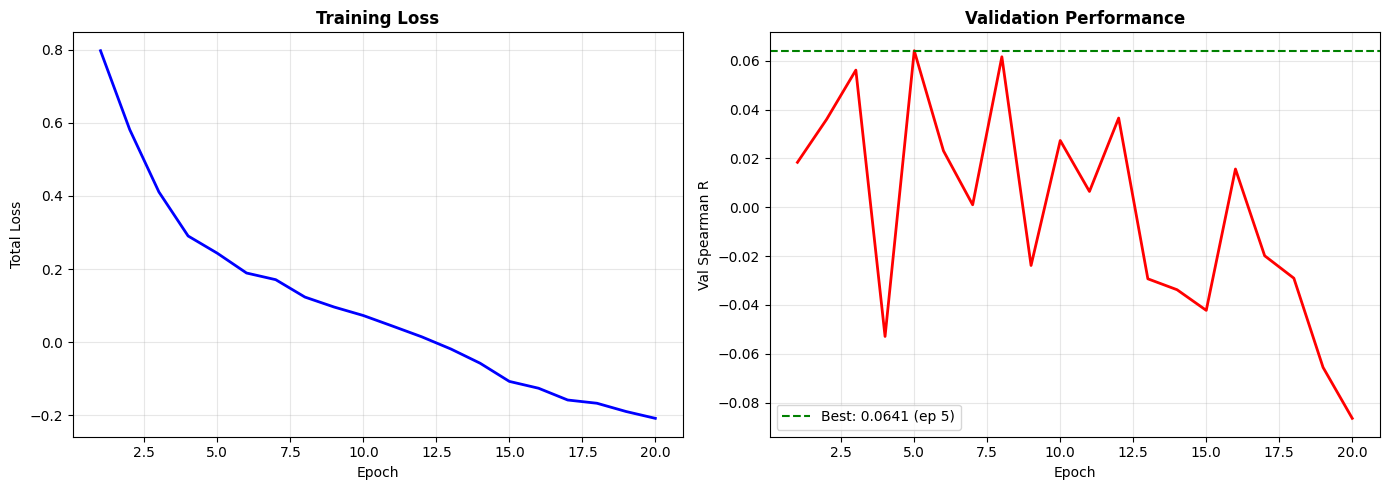

✓ Curves saved.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = [h["epoch"] for h in history]
ax1.plot(ep, [h["train_loss"] for h in history], "b-", lw=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Total Loss")
ax1.set_title("Training Loss", fontweight="bold"); ax1.grid(True, alpha=0.3)
ax2.plot(ep, [h["val_r"] for h in history], "r-", lw=2)
ax2.axhline(best_val_r, color="g", ls="--",
            label=f"Best: {best_val_r:.4f} (ep {best_epoch})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Spearman R")
ax2.set_title("Validation Performance", fontweight="bold")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("✓ Curves saved.")


In [ ]:
import json
import numpy as np
from pathlib import Path

# Recover original (pre-normalisation) training target stats from scaler
original_mean = float(scaler.mean_[0])
original_std  = float(scaler.scale_[0])

# Recover original min/max from training targets
train_targets_orig = scaler.inverse_transform(
    np.array([g.y.item() for g in train_graphs]).reshape(-1, 1)
).flatten()

# ── Save JSON in the exact format the pipeline expects ────────────────────────
scaler_data = {
    "method":        "standard",
    "original_mean": original_mean,
    "original_std":  original_std,
    "original_min":  float(train_targets_orig.min()),
    "original_max":  float(train_targets_orig.max()),
    "n_train_windows": len(train_graphs),
    "target_variable": "PMAT24_A_CR",
    "fold_pkl":      str(PICKLE_PATH),
}

scaler_json_path = OUTPUT_DIR / "pmat_target_scaler.json"
with open(scaler_json_path, "w") as f:
    json.dump(scaler_data, f, indent=2)

# ── Save as joblib (fallback — also checked by teammate's registry) ───────────
try:
    import joblib
    scaler_joblib_path = OUTPUT_DIR / "pmat_target_scaler.joblib"
    joblib.dump(scaler, scaler_joblib_path)
    print(f"✓ Scaler saved as joblib → {scaler_joblib_path}")
except ImportError:
    print("  (joblib not available — JSON version is sufficient)")

print(f"✓ Scaler saved → {scaler_json_path}")
print(f"  method        : standard")
print(f"  original_mean : {original_mean:.4f}")
print(f"  original_std  : {original_std:.4f}")
print(f"  original_min  : {train_targets_orig.min():.4f}")
print(f"  original_max  : {train_targets_orig.max():.4f}")

✓ Scaler saved as joblib → /content/drive/MyDrive/brain_gnn_full/results/braingnn_outer1_inner1_last/pmat_target_scaler.joblib
✓ Scaler saved → /content/drive/MyDrive/brain_gnn_full/results/braingnn_outer1_inner1_last/pmat_target_scaler.json
  method        : standard
  original_mean : 16.6017
  original_std  : 4.5810
  original_min  : 6.0000
  original_max  : 23.0000


## 11. Extract ROI Importance

In [ ]:
@torch.no_grad()
def extract_roi_importance(model, graphs_list, device, n_roi=268):
    model.eval()
    score_sum = np.zeros(n_roi, dtype=np.float64)
    score_cnt = np.zeros(n_roi, dtype=np.float64)
    loader    = DataLoader(graphs_list, batch_size=128, shuffle=False)

    for batch in tqdm(loader, desc="Extracting pooling scores"):
        batch = batch.to(device)
        _, scores1, perm1 = model(batch, return_scores=True)
        scores_np = scores1.cpu().numpy()
        bvec      = batch.batch.cpu().numpy()
        n_g       = int(bvec.max()) + 1
        for gi in range(n_g):
            mask     = (bvec == gi)
            g_scores = scores_np[mask]
            n_g_nodes = g_scores.shape[0]
            lim = min(n_g_nodes, n_roi)
            score_sum[:lim] += g_scores[:lim]
            score_cnt[:lim] += 1

    return score_sum / np.maximum(score_cnt, 1)


roi_importance = extract_roi_importance(model, test_graphs, device, N_ROI)
np.save(OUTPUT_DIR / "roi_importance.npy", roi_importance)

print(f"ROI importance range: {roi_importance.min():.4f} → {roi_importance.max():.4f}")
print(f"Range ratio: {roi_importance.max()/(roi_importance.min()+1e-10):.1f}×")
print("(Higher ratio = TPK loss worked, selected ROIs clearly distinguish themselves)")


Extracting pooling scores:   0%|          | 0/26 [00:00<?, ?it/s]

ROI importance range: -0.2675 → 1.6281
Range ratio: -6.1×
(Higher ratio = TPK loss worked, selected ROIs clearly distinguish themselves)


## 12. Top ROI Table

In [ ]:
import urllib.request

if not os.path.exists(ATLAS_NII):
    print("Downloading Shen-268 atlas...")
    urllib.request.urlretrieve(
        "https://neurovault.org/media/images/8423/shen_2mm_268_parcellation.nii.gz",
        ATLAS_NII)

def get_shen_centroids(path, n_roi=268):
    img = nib.load(path); d = img.get_fdata().astype(int); aff = img.affine
    c   = np.zeros((n_roi, 3))
    for l in range(1, n_roi+1):
        v = np.argwhere(d == l)
        if len(v): c[l-1] = nib.affines.apply_affine(aff, v.mean(0))
    return c

centroids = get_shen_centroids(ATLAS_NII)
np.save(OUTPUT_DIR / "centroids.npy", centroids)
print(f"✓ Centroids: {centroids.shape}")

TOP_N = 20
sorted_idx = np.argsort(roi_importance)[::-1]
rows = []
for rank, idx in enumerate(sorted_idx):
    mni = centroids[idx]
    rows.append({"rank": rank+1, "roi_label": idx+1,
                 "network": roi_network(idx),
                 "mni_x": round(float(mni[0]),1),
                 "mni_y": round(float(mni[1]),1),
                 "mni_z": round(float(mni[2]),1),
                 "score": round(float(roi_importance[idx]),6)})
df_rois = pd.DataFrame(rows)
df_rois.to_csv(OUTPUT_DIR / "roi_ranking.csv", index=False)

print(f"\nTop-{TOP_N} ROIs by pooling score:")
print(f"  {'Rk':<4} {'ROI':>5}  {'MNI x':>7} {'MNI y':>7} {'MNI z':>7}"
      f"  {'Network':<28}  Score")
print(f"  {'-'*72}")
for _, r in df_rois.head(TOP_N).iterrows():
    print(f"  {int(r['rank']):<4} {int(r['roi_label']):>5}"
          f"  {r['mni_x']:>+7.1f} {r['mni_y']:>+7.1f} {r['mni_z']:>+7.1f}"
          f"  {r['network']:<28}  {r['score']:.4f}")


✓ Centroids: (268, 3)

Top-20 ROIs by pooling score:
  Rk     ROI    MNI x   MNI y   MNI z  Network                       Score
  ------------------------------------------------------------------------
  1        1    +14.1   +56.7   -16.7  Medial Frontal                1.6281
  2      137     -7.8   +39.8   -21.4  Subcortical / Cerebellum      1.5182
  3      195    -37.8   -13.1   -29.2  Visual I                      1.4836
  4      189    -22.8    +9.0   -38.7  Visual I                      1.4209
  5      202    -29.9    -5.8   -40.9  Visual II                     1.3771
  6      139    -18.2   +57.0   -14.3  Subcortical / Cerebellum      1.3304
  7      255     -6.4   -54.7   -26.2  Visual Association            1.3157
  8      235    -21.5    -4.1   -29.3  Visual Association            1.2837
  9       51    +27.2   +11.6   -39.2  Frontoparietal                1.2834
  10       4    +15.6   +34.2   -22.5  Medial Frontal                1.2489
  11     196    -51.8   -18.2   -28.8

## 13. Edge Importance & Brain Plots

Mean connectivity:   0%|          | 0/3240 [00:00<?, ?it/s]

Building full edge ranking (35,778 pairs)...
✓ Full ranking saved (35778 edges) → edge_ranking_full.csv
✓ Top-20 saved → edge_ranking_top20.csv

Top-20 connections by edge importance:

  Rk   ROI_i ROI_j  Network_i                     Network_j                     PoolSc_i  PoolSc_j  ConnStr  Importance
  -------------------------------------------------------------------------------------------------------------------
  1        1   139  Medial Frontal                Subcortical / Cerebellum        1.6281    1.3304   0.1309  0.110333
  2      101   244  Default Mode                  Visual Association              0.9347    1.1108   0.2228  0.102721
  3      195   202  Visual I                      Visual II                       1.4836    1.3771   0.1110  0.088944
  4        1   137  Medial Frontal                Subcortical / Cerebellum        1.6281    1.5182   0.0938  0.088351
  5      189   202  Visual I                      Visual II                       1.4209    1.3771   0.11

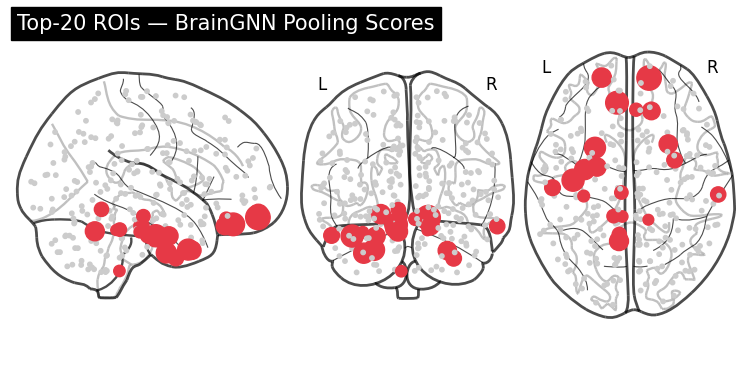


✓ ROI markers plot saved.


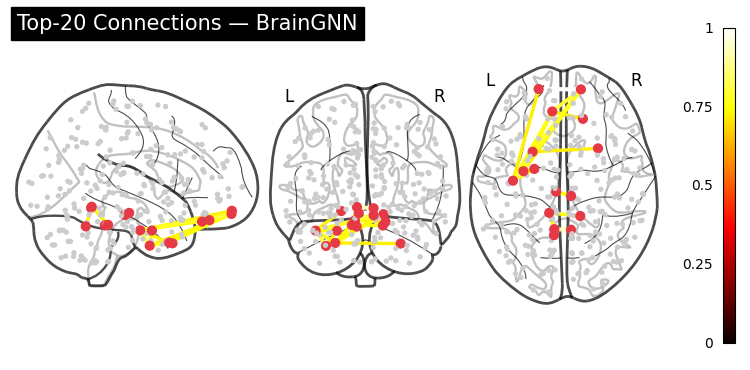

✓ Connectome plot saved.


In [ ]:
from nilearn import plotting

# ── Mean connectivity across test windows ─────────────────────────────────────
conn_sum = np.zeros((N_ROI, N_ROI), dtype=np.float64)
for g in tqdm(test_graphs, desc="Mean connectivity"):
    conn_sum += g.x.abs().numpy()
mean_conn = (conn_sum / len(test_graphs)).astype(np.float32)

# ── Edge importance = outer(pool_scores_norm) × connection_strength ───────────
p_norm = (roi_importance - roi_importance.min())
p_norm /= (p_norm.max() + 1e-8)
edge_imp = np.outer(p_norm, p_norm) * mean_conn
np.fill_diagonal(edge_imp, 0)  # remove self-connections
np.save(OUTPUT_DIR / "edge_importance.npy", edge_imp)

# =============================================================================
# Save CSV 1: All 35,778 unique ROI pairs — full ranking
# =============================================================================
print("Building full edge ranking (35,778 pairs)...")
upper_idx = np.triu_indices(N_ROI, k=1)   # upper triangle, no diagonal
i_arr     = upper_idx[0]
j_arr     = upper_idx[1]
scores_arr = edge_imp[i_arr, j_arr]

# Global max for normalisation (across ALL edges, not just top-20)
global_max = float(scores_arr.max())

# Sort by importance descending
sort_order = np.argsort(scores_arr)[::-1]

rows_full = []
for rank_idx, flat_idx in enumerate(sort_order):
    i = int(i_arr[flat_idx])
    j = int(j_arr[flat_idx])
    mni_i = centroids[i]
    mni_j = centroids[j]
    raw_score  = float(scores_arr[flat_idx])
    norm_score = raw_score / (global_max + 1e-10)   # ← normalised [0, 1]
    rows_full.append({
        "rank":              rank_idx + 1,
        "roi_i":             i + 1,
        "roi_j":             j + 1,
        "network_i":         roi_network(i),
        "network_j":         roi_network(j),
        "pool_score_i":      round(float(roi_importance[i]), 6),
        "pool_score_j":      round(float(roi_importance[j]), 6),
        "pool_score_norm_i": round(float(p_norm[i]), 6),
        "pool_score_norm_j": round(float(p_norm[j]), 6),
        "conn_strength":     round(float(mean_conn[i, j]), 6),
        "edge_importance":   round(float(scores_arr[flat_idx]), 6),
        "edge_importance_norm":    round(norm_score, 6),   # ← added
        "mni_ix": round(float(mni_i[0]), 1),
        "mni_iy": round(float(mni_i[1]), 1),
        "mni_iz": round(float(mni_i[2]), 1),
        "mni_jx": round(float(mni_j[0]), 1),
        "mni_jy": round(float(mni_j[1]), 1),
        "mni_jz": round(float(mni_j[2]), 1),
    })

df_full = pd.DataFrame(rows_full)
path_full = OUTPUT_DIR / "edge_ranking_full.csv"
df_full.to_csv(path_full, index=False)
print(f"✓ Full ranking saved ({len(df_full)} edges) → edge_ranking_full.csv")

# =============================================================================
# Save CSV 2: Top-N edges only — quick reference
# =============================================================================
TOP_E   = 20
df_top  = df_full.head(TOP_E).copy()
path_top = OUTPUT_DIR / "edge_ranking_top20.csv"
df_top.to_csv(path_top, index=False)
print(f"✓ Top-{TOP_E} saved → edge_ranking_top20.csv")

# ── Print top-N table ──────────────────────────────────────────────────────────
print(f"\nTop-{TOP_E} connections by edge importance:")
print(f"\n  {'Rk':<4} {'ROI_i':>5} {'ROI_j':>5}  "
      f"{'Network_i':<28}  {'Network_j':<28}  "
      f"{'PoolSc_i':>8}  {'PoolSc_j':>8}  {'ConnStr':>7}  Importance")
print(f"  {'-'*115}")
for _, row in df_top.iterrows():
    print(f"  {int(row['rank']):<4} {int(row['roi_i']):>5} {int(row['roi_j']):>5}  "
          f"{row['network_i']:<28}  {row['network_j']:<28}  "
          f"{row['pool_score_i']:>8.4f}  {row['pool_score_j']:>8.4f}  "
          f"{row['conn_strength']:>7.4f}  {row['edge_importance']:.6f}")

# ── Quick stats on full distribution ──────────────────────────────────────────
print(f"\nFull edge importance distribution:")
print(f"  Min   : {df_full['edge_importance'].min():.6f}")
print(f"  Max   : {df_full['edge_importance'].max():.6f}")
print(f"  Mean  : {df_full['edge_importance'].mean():.6f}")
print(f"  Median: {df_full['edge_importance'].median():.6f}")
print(f"  Edges > 0.01 : {(df_full['edge_importance'] > 0.01).sum()}")
print(f"  Edges > 0.05 : {(df_full['edge_importance'] > 0.05).sum()}")
print(f"  Edges > 0.10 : {(df_full['edge_importance'] > 0.10).sum()}")

# =============================================================================
# Brain plots
# =============================================================================

# ── ROI markers plot ───────────────────────────────────────────────────────────
sorted_idx = np.argsort(roi_importance)[::-1]
top_idx    = sorted_idx[:TOP_N]
top_scores = roi_importance[top_idx]

sizes   = np.full(N_ROI, 10, dtype=float)
colours = ["#cccccc"] * N_ROI
for rank, idx in enumerate(top_idx):
    sizes[idx]   = 60 + 250 * float(
        (top_scores[rank] - top_scores.min()) /
        (top_scores.max() - top_scores.min() + 1e-8))
    colours[idx] = "#e63946"

fig = plotting.plot_connectome(
    np.zeros((N_ROI, N_ROI)), centroids,
    node_color=colours, node_size=sizes,
    display_mode="ortho", colorbar=False,
    title=f"Top-{TOP_N} ROIs — BrainGNN Pooling Scores")
fig.savefig(OUTPUT_DIR / "roi_markers.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print(f"\n✓ ROI markers plot saved.")

# ── Connectome plot (top-N edges) ─────────────────────────────────────────────
adj_plot = np.zeros((N_ROI, N_ROI))
max_s    = df_top["edge_importance"].max()
for _, row in df_top.iterrows():
    i = int(row["roi_i"]) - 1
    j = int(row["roi_j"]) - 1
    w = row["edge_importance_norm"]
    adj_plot[i, j] = w
    adj_plot[j, i] = w

involved    = set(int(r["roi_i"])-1 for _, r in df_top.iterrows()) | \
              set(int(r["roi_j"])-1 for _, r in df_top.iterrows())
node_colors = ["#e63946" if r in involved else "#cccccc" for r in range(N_ROI)]
node_sizes  = np.where([r in involved for r in range(N_ROI)], 40, 8)

fig2 = plotting.plot_connectome(
    adj_plot, centroids,
    node_color=node_colors, node_size=node_sizes,
    edge_cmap="hot", edge_vmin=0, edge_vmax=1,
    display_mode="ortho", colorbar=True,
    title=f"Top-{TOP_E} Connections — BrainGNN")
fig2.savefig(OUTPUT_DIR / "connectome.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print(f"✓ Connectome plot saved.")

In [ ]:
ram_used()
print("\n" + "="*55)
print("ALL DONE! 🎉")
print("="*55)
print(f"Outputs: {OUTPUT_DIR}")


  RAM: 21.2/53.0 GB (40%)

ALL DONE! 🎉
Outputs: /content/drive/MyDrive/brain_gnn_full/results/braingnn_outer1_inner1_last
